In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ============================================================
# Dataset
# x0 ~ N(10, 2)
# mean = 10
# variance = 2
# std = sqrt(2)
# ============================================================

mu = 10.0
var = 2.0
std = np.sqrt(var)

N = 10000

x_np = np.random.normal(mu, std, N).astype(np.float32)

# exact score
# score(x) = -(x - mu) / var
score_np = -(x_np - mu) / var

x_train = torch.tensor(x_np).view(-1, 1)
score_train = torch.tensor(score_np).view(-1, 1)



In [3]:
# ============================================================
# Score Network
# ============================================================

class ScoreNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),

            nn.Linear(64, 64),
            nn.SiLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ScoreNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [4]:
# ============================================================
# Training
# ============================================================

epochs = 3000

L_ESM_history = []
L_ISM_history = []
L_DSM_history = []
I_DSM_history = []

x_train.requires_grad_(True)

for epoch in range(epochs):

    # network prediction
    pred_score = model(x_train)

    sigma = 5.0
    noise = sigma * torch.randn_like(x_train)
    x_noisy = x_train + noise

    # marginal score of p_sigma(x)
    # x_noisy ~ N(mu, var + sigma^2)
    marginal_score = -(x_noisy - mu) / (var + sigma**2)

    # conditional score of p(x | x0)
    conditional_score = -(x_noisy - x_train) / (sigma**2)

    pred_score_noisy = model(x_noisy)

    # ========================================================
    # 1. L_ESM
    # ========================================================

    # L_ESM on noisy marginal distribution
    L_ESM = ((pred_score_noisy - marginal_score) ** 2).mean()

    # ========================================================
    # 2. L_ISM
    # ||S||^2 + 2 div S
    # ========================================================

    x_noisy.requires_grad_(True)

    pred_score_noisy = model(x_noisy)

    div_score = torch.autograd.grad(
        outputs=pred_score_noisy.sum(),
        inputs=x_noisy,
        create_graph=True
    )[0]

    L_ISM = (pred_score_noisy**2 + 2 * div_score).mean()

    # ========================================================
    # 3. L_DSM
    # ========================================================
    # L_DSM relation
    term1 = (marginal_score ** 2).mean()
    term2 = (conditional_score ** 2).mean()

    L_DSM = L_ESM - term1 + term2

    # ========================================================
    # 4. Indicator I_DSM
    # ========================================================

    inner_product = (pred_score_noisy * conditional_score)

    I_DSM = (pred_score_noisy**2- inner_product).mean()

    # ========================================================
    # train
    # ========================================================

    loss = L_ESM

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ========================================================
    # record
    # ========================================================

    L_ESM_history.append(L_ESM.item())
    L_ISM_history.append(L_ISM.item())
    L_DSM_history.append(L_DSM.item())
    I_DSM_history.append(I_DSM.item())

    # ========================================================
    # print
    # ========================================================

    if epoch % 300 == 0:

        print(
            f"Epoch {epoch:4d} | "
            f"L_ESM = {L_ESM.item():.8f} | "
            f"L_ISM = {L_ISM.item():.8f} | "
            f"L_DSM = {L_DSM.item():.8f} | "
            f"I_DSM = {I_DSM.item():.8f}"
        )

Epoch    0 | L_ESM = 2.22234082 | L_ISM = 2.18670225 | L_DSM = 2.22505379 | I_DSM = 2.05838418
Epoch  300 | L_ESM = 0.00003059 | L_ISM = -0.03672972 | L_DSM = 0.00308527 | I_DSM = -0.00005643
Epoch  600 | L_ESM = 0.00000880 | L_ISM = -0.03806579 | L_DSM = 0.00295413 | I_DSM = -0.00001973
Epoch  900 | L_ESM = 0.00000329 | L_ISM = -0.03813675 | L_DSM = 0.00277423 | I_DSM = 0.00007980
Epoch 1200 | L_ESM = 0.00000186 | L_ISM = -0.03685272 | L_DSM = 0.00318030 | I_DSM = -0.00011343
Epoch 1500 | L_ESM = 0.00000125 | L_ISM = -0.03676642 | L_DSM = 0.00300986 | I_DSM = -0.00002571
Epoch 1800 | L_ESM = 0.00000093 | L_ISM = -0.03670571 | L_DSM = 0.00295114 | I_DSM = -0.00002256
Epoch 2100 | L_ESM = 0.00000071 | L_ISM = -0.03622556 | L_DSM = 0.00288294 | I_DSM = 0.00001755
Epoch 2400 | L_ESM = 0.00000039 | L_ISM = -0.03658516 | L_DSM = 0.00291599 | I_DSM = 0.00001385
Epoch 2700 | L_ESM = 0.00000027 | L_ISM = -0.03732393 | L_DSM = 0.00312749 | I_DSM = -0.00008468


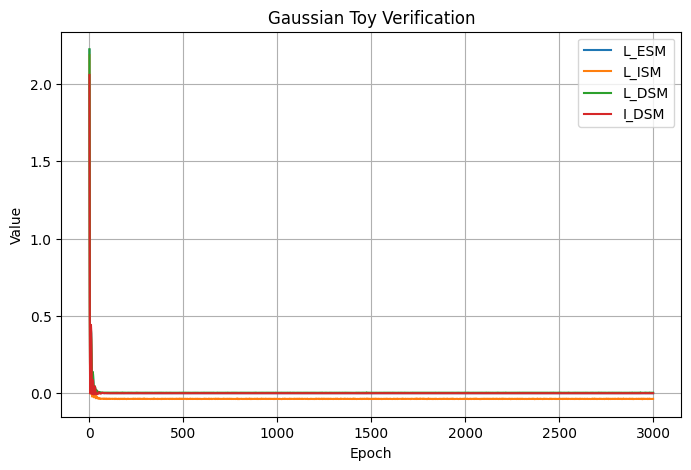

In [5]:
# ============================================================
# Plot losses
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Gaussian Toy Verification")
plt.legend()
plt.grid(True)

plt.show()

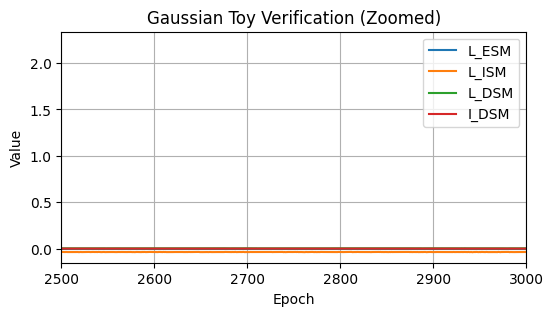

In [6]:
plt.figure(figsize=(6,3))

plt.plot(L_ESM_history, label='L_ESM')
plt.plot(L_ISM_history, label='L_ISM')
plt.plot(L_DSM_history, label='L_DSM')
plt.plot(I_DSM_history, label='I_DSM')

# zoom in
plt.xlim(2500, 3000)

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Gaussian Toy Verification (Zoomed)")
plt.legend()
plt.grid(True)

plt.show()

# Langevin sampling ((這邊怪))

In [7]:
# ============================================================
# Stable Langevin Sampling
# ============================================================

model.eval()

steps = 3000
step_size = 1e-3

#x_sample = torch.randn(5000, 1) * 2 + 10
x_sample = torch.randn(5000, 1) 

with torch.no_grad():
    for _ in range(steps):
        score = model(x_sample)
        noise = torch.randn_like(x_sample)

        x_sample = (
            x_sample
            + step_size * score
            + torch.sqrt(torch.tensor(2 * step_size)) * noise
        )

samples = x_sample.cpu().numpy().flatten()

print("Generated mean:", samples.mean())
print("Generated std:", samples.std())

Generated mean: 1.0373125
Generated std: 2.4898312


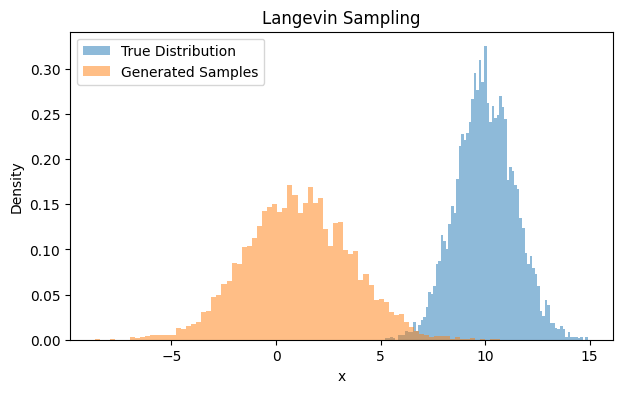

In [8]:
# ============================================================
# Plot generated samples
# ============================================================

true_samples = np.random.normal(
    mu,
    np.sqrt(var),
    5000
)

plt.figure(figsize=(7,4))

plt.hist(
    true_samples,
    bins=80,
    density=True,
    alpha=0.5,
    label='True Distribution'
)

plt.hist(
    samples,
    bins=80,
    density=True,
    alpha=0.5,
    label='Generated Samples'
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Langevin Sampling")
plt.legend()

plt.show()

In [9]:
print(samples.mean())
print(samples.std())

1.0373125
2.4898312


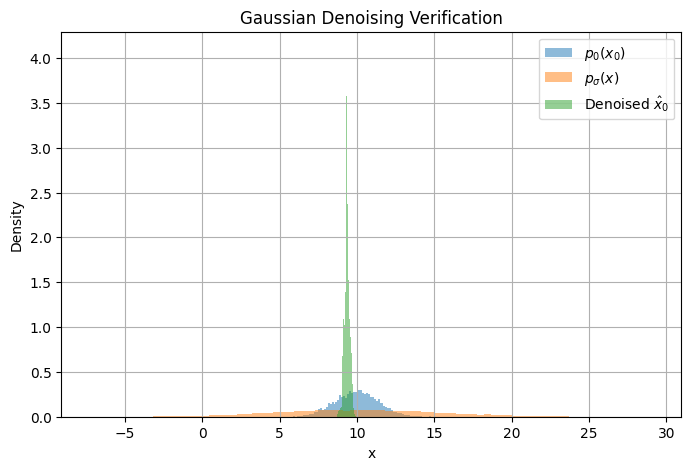

In [10]:
# ============================================================
# True distributions
# ============================================================

N_plot = 5000

# original distribution p0(x0)
x0_true = np.random.normal(
    mu,
    np.sqrt(var),
    N_plot
)

# noisy marginal distribution p_sigma(x)
x_true = np.random.normal(
    mu,
    np.sqrt(var + sigma**2),
    N_plot
)

## generated samples from Langevin
generated = samples
# denoise generated samples back to x0 estimate
generated_tensor = torch.tensor(samples, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    score_generated = model(generated_tensor)
    x0_hat = generated_tensor + (sigma**2) * score_generated

#x0_hat = x0_hat.numpy().flatten()
plt.figure(figsize=(8,5))

plt.hist(x0_true, bins=80, density=True, alpha=0.5, label=r'$p_0(x_0)$')
plt.hist(x_true, bins=80, density=True, alpha=0.5, label=r'$p_\sigma(x)$')
#plt.hist(generated, bins=80, density=True, alpha=0.5, label='Generated from $p_\sigma$')
plt.hist(x0_hat, bins=80, density=True, alpha=0.5, label=r'Denoised $\hat{x}_0$')

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gaussian Denoising Verification")
plt.legend()
plt.grid(True)
plt.show()

# 0603 固定sigma比較steps
steps:
* 500步
* 1000步

In [11]:
# ============================================================
# Compare Langevin Sampling: 500 vs 1000 steps
# ============================================================

model.eval()

steps_list = [1000 , 2000, 3000, 4000, 5000]
step_size = 1e-3
num_samples = 5000

samples_by_steps = {}

with torch.no_grad():
    for steps in steps_list:

        x_sample = torch.randn(num_samples, 1) #* np.sqrt(var + sigma**2) + mu

        for _ in range(steps):
            score = model(x_sample)
            noise = torch.randn_like(x_sample)

            x_sample = (
                x_sample
                + step_size * score
                + torch.sqrt(torch.tensor(2 * step_size)) * noise
            )

        samples = x_sample.cpu().numpy().flatten()
        samples_by_steps[steps] = samples

        print(f"Steps = {steps}")
        print("Generated mean:", samples.mean())
        print("Generated std:", samples.std())
        print()

Steps = 1000
Generated mean: 0.39051354
Generated std: 1.7075495

Steps = 2000
Generated mean: 0.7109358
Generated std: 2.1404097

Steps = 3000
Generated mean: 1.0341345
Generated std: 2.4720142

Steps = 4000
Generated mean: 1.3339187
Generated std: 2.8014278

Steps = 5000
Generated mean: 1.7028291
Generated std: 2.9720495



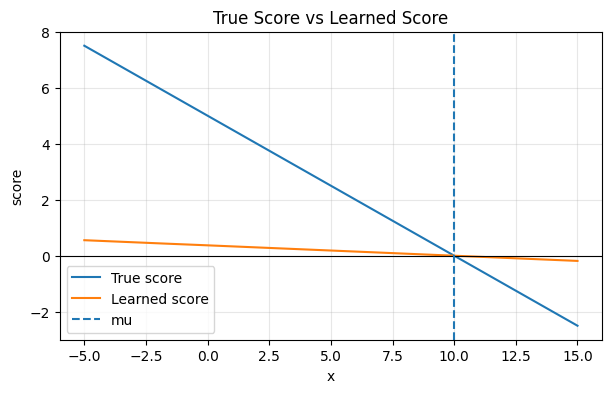

In [12]:
x_grid = torch.linspace(-5, 15, 500).reshape(-1, 1)

with torch.no_grad():
    learned_score = model(x_grid).cpu().numpy().flatten()

x_np = x_grid.cpu().numpy().flatten()
true_score = -(x_np - mu) / var

plt.figure(figsize=(7, 4))
plt.plot(x_np, true_score, label="True score")
plt.plot(x_np, learned_score, label="Learned score")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(mu, linestyle="--", label="mu")
plt.xlabel("x")
plt.ylabel("score")
plt.title("True Score vs Learned Score")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

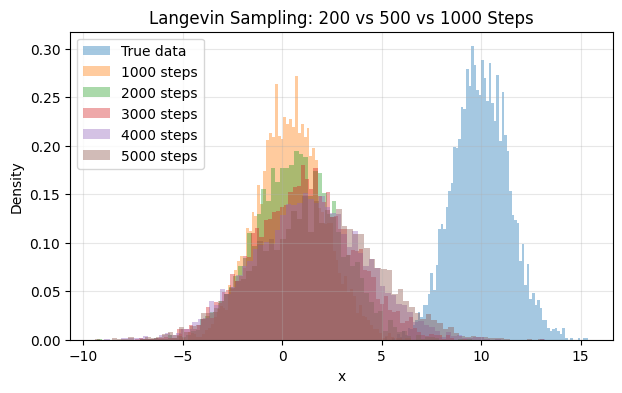

In [13]:
# ============================================================
# Plot 500 vs 1000 Langevin Sampling
# ============================================================

plt.figure(figsize=(7, 4))

true_samples = np.random.normal(mu, np.sqrt(var), 5000)
plt.hist(true_samples, bins=80, density=True, alpha=0.4, label="True data")

for steps in steps_list:
    plt.hist(samples_by_steps[steps], bins=80, density=True, alpha=0.4, label=f"{steps} steps")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Langevin Sampling: 200 vs 500 vs 1000 Steps")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 重開 Reconstruction (0604)

In [14]:
# ============================================================
# Gaussian Denoising using learned score
# ============================================================

model.eval()

num_samples = 5000

# sample clean data
x0 = torch.randn(num_samples, 1) * np.sqrt(var) + mu

# add Gaussian noise
noise = torch.randn_like(x0)
x_noisy = x0 + sigma * noise

# denoise by Tweedie's formula
with torch.no_grad():
    score = model(x_noisy)
    x_denoised = x_noisy + sigma**2 * score

x0_np = x0.cpu().numpy().flatten()
x_noisy_np = x_noisy.cpu().numpy().flatten()
x_denoised_np = x_denoised.cpu().numpy().flatten()

print("Clean x0 mean/std:", x0_np.mean(), x0_np.std())
print("Noisy x mean/std:", x_noisy_np.mean(), x_noisy_np.std())
print("Denoised x0_hat mean/std:", x_denoised_np.mean(), x_denoised_np.std())

Clean x0 mean/std: 10.017238 1.4128604
Noisy x mean/std: 9.986622 5.192485
Denoised x0_hat mean/std: 9.998165 0.38432646


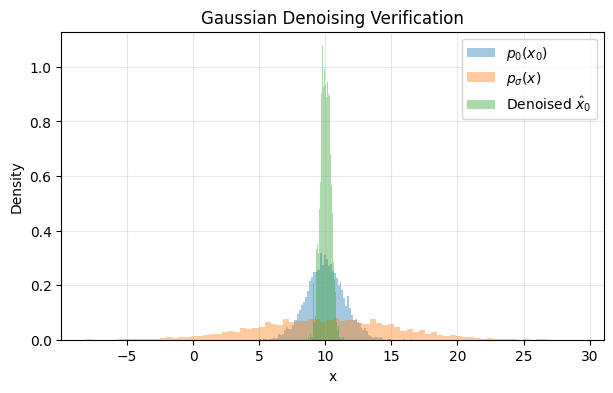

In [15]:
plt.figure(figsize=(7, 4))

plt.hist(x0_np, bins=80, density=True, alpha=0.4, label=r"$p_0(x_0)$")
plt.hist(x_noisy_np, bins=80, density=True, alpha=0.4, label=r"$p_\sigma(x)$")
plt.hist(x_denoised_np, bins=80, density=True, alpha=0.4, label=r"Denoised $\hat{x}_0$")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Gaussian Denoising Verification")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
true_score = -(x_noisy - mu) / (var + sigma**2)
x_denoised_true = x_noisy + sigma**2 * true_score

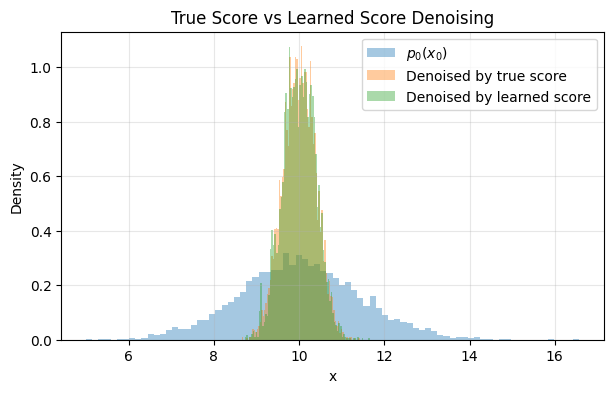

In [17]:
plt.figure(figsize=(7, 4))

plt.hist(x0_np, bins=80, density=True, alpha=0.4, label=r"$p_0(x_0)$")
plt.hist(x_denoised_true.cpu().numpy().flatten(), bins=80, density=True, alpha=0.4, label="Denoised by true score")
plt.hist(x_denoised_np, bins=80, density=True, alpha=0.4, label="Denoised by learned score")

plt.xlabel("x")
plt.ylabel("Density")
plt.title("True Score vs Learned Score Denoising")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

因為1D Gaussian不是sampling, 而是Denoised.  
所以如果要像是分布數來看的話，我們這邊用一個參數 α∈[0,1]來代表denoised 的程度  
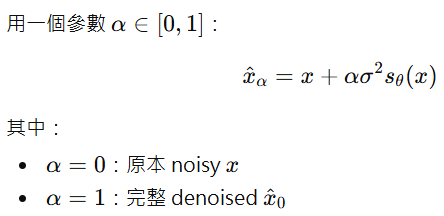

In [18]:
# ============================================================
# Stepwise Gaussian Denoising
# ============================================================

model.eval()

num_samples = 5000
alphas = [0, 0.25, 0.5, 0.75, 1.0]

x0 = torch.randn(num_samples, 1) * np.sqrt(var) + mu
noise = torch.randn_like(x0)
x_noisy = x0 + sigma * noise

with torch.no_grad():
    score = model(x_noisy)

denoised_by_alpha = {}

for alpha in alphas:
    x_alpha = x_noisy + alpha * sigma**2 * score
    denoised_by_alpha[alpha] = x_alpha.cpu().numpy().flatten()

x0_np = x0.cpu().numpy().flatten()
x_noisy_np = x_noisy.cpu().numpy().flatten()

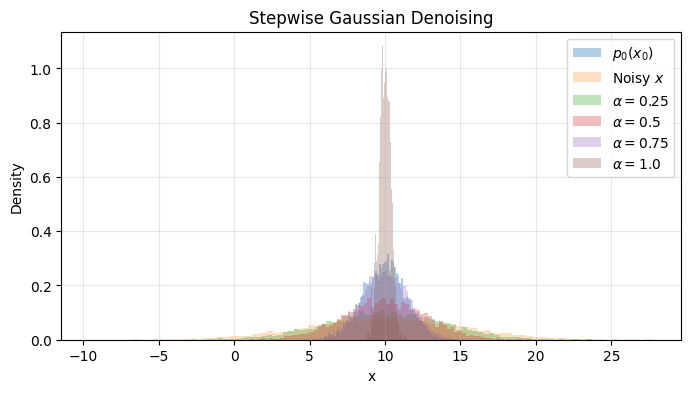

In [19]:
plt.figure(figsize=(8, 4))

plt.hist(x0_np, bins=80, density=True, alpha=0.35, label=r"$p_0(x_0)$")
plt.hist(x_noisy_np, bins=80, density=True, alpha=0.25, label=r"Noisy $x$")

for alpha in alphas[1:]:
    plt.hist(
        denoised_by_alpha[alpha],
        bins=80,
        density=True,
        alpha=0.3,
        label=fr"$\alpha={alpha}$"
    )

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Stepwise Gaussian Denoising")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
# ============================================================
# Score comparison across denoising levels
# ============================================================

model.eval()

alphas = [0, 0.25, 0.5, 0.75, 1.0]
score_means = []
score_abs_means = []
score_sq_means = []

with torch.no_grad():
    # score at noisy x
    base_score = model(x_noisy)

    for alpha in alphas:
        # partially denoised sample
        x_alpha = x_noisy + alpha * sigma**2 * base_score

        # score at this denoised level
        score_alpha = model(x_alpha)

        score_means.append(score_alpha.mean().item())
        score_abs_means.append(score_alpha.abs().mean().item())
        score_sq_means.append((score_alpha**2).mean().item())

        print(f"alpha = {alpha}")
        print("x_alpha mean:", x_alpha.mean().item())
        print("x_alpha std:", x_alpha.std().item())
        print("score mean:", score_alpha.mean().item())
        print("E|score|:", score_alpha.abs().mean().item())
        print("E[score^2]:", (score_alpha**2).mean().item())
        print()

alpha = 0
x_alpha mean: 9.971183776855469
x_alpha std: 5.176753520965576
score mean: 0.0010300875874236226
E|score|: 0.15272055566310883
E[score^2]: 0.0367530882358551

alpha = 0.25
x_alpha mean: 9.977621078491211
x_alpha std: 3.978461265563965
score mean: 0.0008057182421907783
E|score|: 0.11733316630125046
E[score^2]: 0.02170712873339653

alpha = 0.5
x_alpha mean: 9.98405933380127
x_alpha std: 2.780172348022461
score mean: 0.0005810509319417179
E|score|: 0.08191919326782227
E[score^2]: 0.010583208873867989

alpha = 0.75
x_alpha mean: 9.990498542785645
x_alpha std: 1.581894040107727
score mean: 0.0003161724307574332
E|score|: 0.04653427004814148
E[score^2]: 0.003409062512218952

alpha = 1.0
x_alpha mean: 9.996935844421387
x_alpha std: 0.3837263882160187
score mean: 7.268518675118685e-05
E|score|: 0.011312087066471577
E[score^2]: 0.00019943770894315094



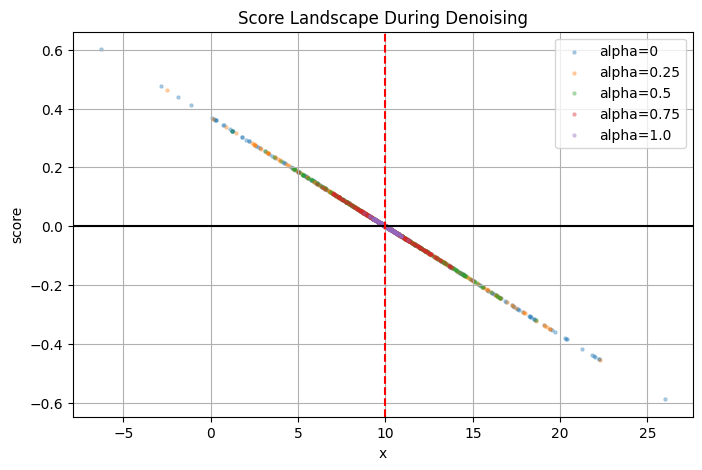

In [24]:
plt.figure(figsize=(8,5))

with torch.no_grad():

    for alpha in alphas:

        x_alpha = x_noisy + alpha * sigma**2 * base_score

        score_alpha = model(x_alpha)

        plt.scatter(
            x_alpha.cpu().numpy()[::20],
            score_alpha.cpu().numpy()[::20],
            s=5,
            alpha=0.3,
            label=f"alpha={alpha}"
        )

plt.axhline(0,color='black')
plt.axvline(mu,color='red',linestyle='--')

plt.xlabel("x")
plt.ylabel("score")
plt.title("Score Landscape During Denoising")
plt.legend()
plt.grid()
plt.show()